# Version with water under the prism

# Interferometric Reflectivity Dip : simulation of a complete system to study beam narrowing

The objective of this notebook is to simulate and optimize an experimental setup that leverages interferences between reflected beam and surface plasmon to achieve beam narrowing. The resulting impact on the resolution of SPR-based sensors is evaluated, offering insights into the potential applications of this effect.

### Importation of the needed libraries

PyMoosh is a open source, user-friendly library for the optical study of multilayered structures, written in Python. The "my_module" library corresponds to a module which contains home made functions needed for this work.

In [1]:
import sys
import os

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.fft import fft2, fftshift, ifft2
from scipy.integrate import trapezoid
import PyMoosh as PM
import my_module as my_mod

font = {'family' : 'DejaVu Sans',
        'weight' : 'normal',
        'size'   : 18}

plt.rc('font', **font)

SAVE_MODE = True # state variable to set if the plots are saved in separated files
save_formats = ["pdf", "svg"] # list with the formats to use to save plots

### Beam initialisation

Initialisation of the incident magnetic field (2D Gaussian beam): wavelength, wave vector, waists, spatial centers and spectral centers. Definition of the beam incidence (fixed to the optimal value determined an other notebook), the spatial window studied and the number of points considered. The distances are provided in $nm$.

The magnetic field expression (TM to be able to excite surface plasmon so $H_y$ in fact) is:
\begin{equation*}
H(X,Y,w_x,w_y,x_0,y_0,\alpha_0,\beta_0)=e^{-\left(\dfrac{Y-y_0}{w_y}\right)^2-\left(\dfrac{X-x_0}{w_x}\right)^2}e^{-i(\alpha_0(X-x_0)+\beta_0(Y-y_0))}.
\end{equation*}

In the following, the magnetic field amplitude will be plotted at several step along the system. It is possible to plot the amplitude through 3D visualisation (using plot_surface) or through 2D visualisation (using contourf). The 3D visualisation is way more demanding in term of computational ressources and often not really needed, this is why 2D visualisation is mainly used.


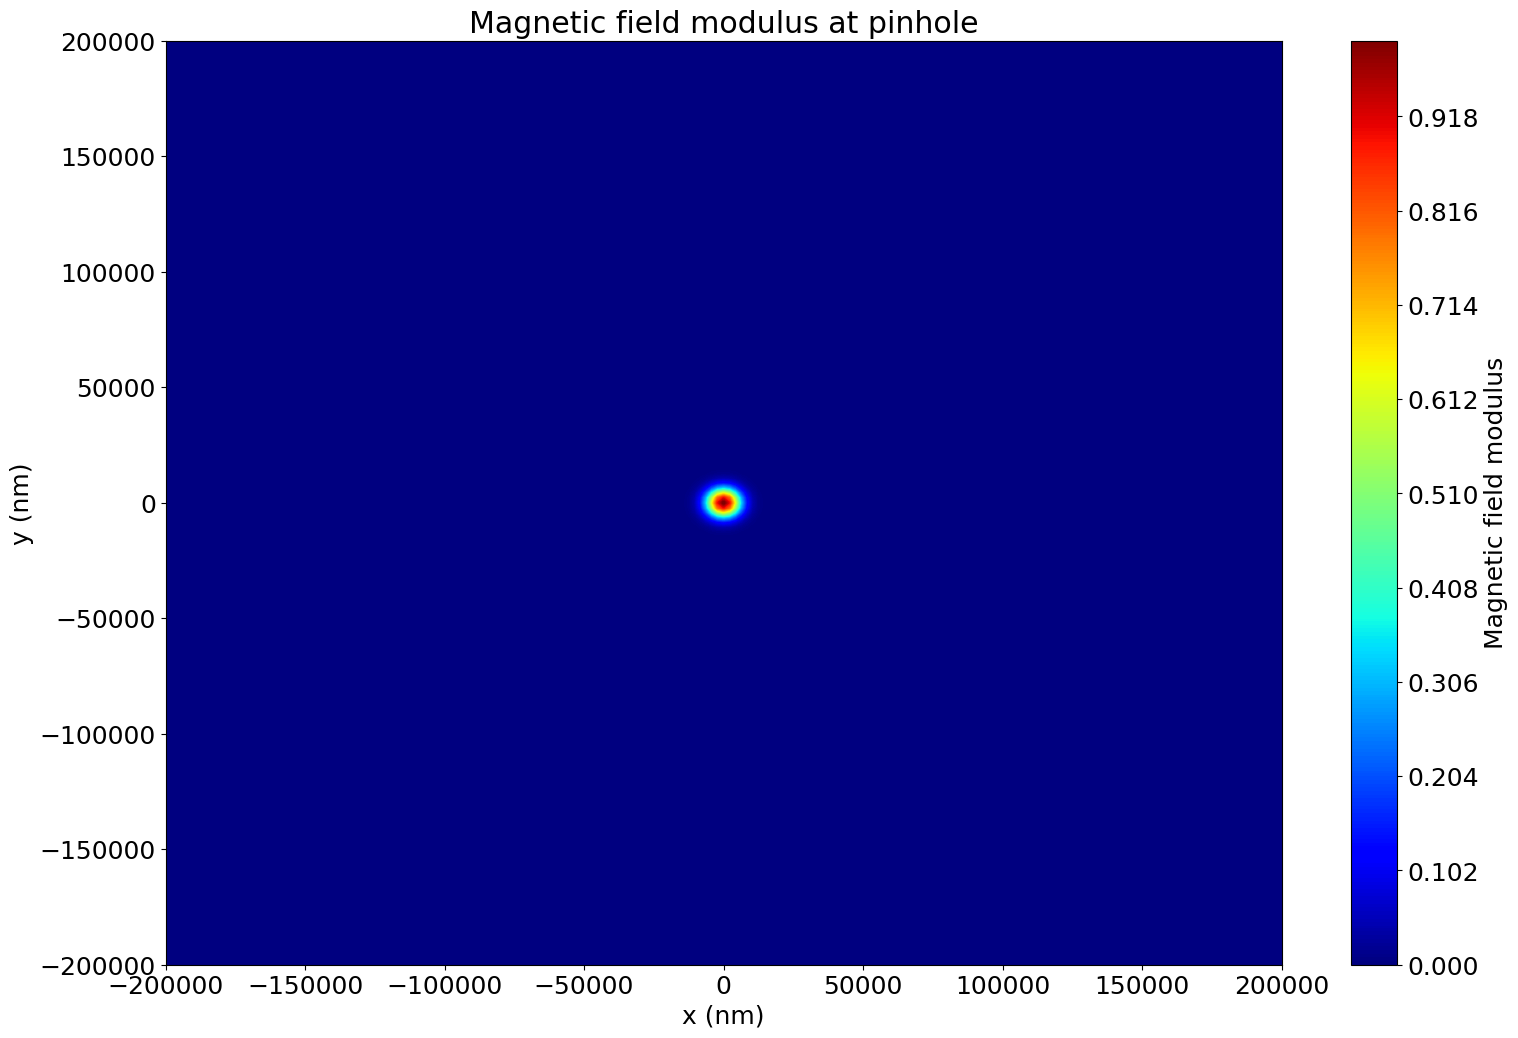

In [2]:
# parameters initialisation
n1 = 1 # air refractive index
wavelength = 632.8
k0 = 2 * np.pi / wavelength
N = 100
wx = 5690
wy = 5690 # wx and wy are the same and will be affected the same way in the optical systems
alpha0 = 0
beta0 = 0
x0 = 0
y0 = 0
inc = 73.38
d = 400000

# the x and y-axes considered
x = np.linspace(-N, N, 2 * N + 1) * (d / 2) / N
y = np.linspace(-N, N, 2 * N + 1) * (d / 2) / N

# grids of the axes
X, Y = np.meshgrid(x, y)

# determination of the magnetic field on the 2D grid corresponding to a Gaussian beam
U = my_mod.gauss2D(X, Y, wx, wy, x0, y0, alpha0, beta0)

# plot of the field at the pinhole with 3D visualisation

# fig=plt.figure(figsize=(12,8))
# ax = fig.add_subplot(111, projection='3d')
# surf = ax.plot_surface(X, Y, abs(U), cmap='jet', edgecolor='none',rcount=2*N+1,ccount=2*N+1,vmin=np.min(abs(U)),vmax=np.max(abs(U)))
# fig.colorbar(surf)
# ax.set_xlabel('x (nm)')
# ax.set_ylabel('y (nm)')
# ax.set_zlabel('|U|')
# ax.set_title('Field at pinhole')
# ax.view_init(elev=90,azim=0);

# plot of the field (beam) at the pinhole with 2D visualisation

fig = plt.figure(figsize=(18, 12))
ax = fig.add_subplot(111)
contour = ax.contourf(X, Y, np.abs(U), levels=500, cmap='jet')
contour.set_edgecolor("face")
cbar = fig.colorbar(contour)
cbar.set_label('Magnetic field modulus')
ax.set_xlabel('x (nm)')
ax.set_ylabel('y (nm)')
ax.set_title('Magnetic field modulus at pinhole');
if SAVE_MODE:
    for file_ext in save_formats:
        plt.savefig(f"Plots/{file_ext}/setup/H_module_at_pinhole.{file_ext}", bbox_inches="tight")


### First optical system

Beam propagation through the first optical system (lens + spherical diopter) SO1. The propagation is done using geometrical optic, assuming that doing the image of the beam (waists) through SO1 is equivalent to the complete propagation but way less computationally demanding (the propagtion using Fourier optic is not easily accessible).

Knowing the optimal waist that optimise the beam narrowing (determined in an other notebook), one know the SO1 magnification to target. The optimisation of SO1 is made with this target using realistic lens and spherical diopter (corresponding to a plan convex lens).

The geometrical parameter of SO1 are provided in $mm$.

The spherical diopter corresponds to the top part of a prism, here a plan convex lens is considered as prism : the LA1951-A from THORLABS.

Optimal waist set and corresponding magnification define in a dedicated cell.

In [3]:
wcible=46089 # the optimal waist in nm
Gcible=wcible/wx # the targeted magnification

The SO1 optimisation.

In [4]:
# SO1
# algebric distances in mm
f1 = 30  # lens focus
n2 = 1.515  # glass refractive index
SC = 13.1  # radius of curvature of the spherical diopter (or plan convex lens)
ec = 11.7  # thickness at the center of the prism (spherical diopter = plan convex lens)
SI = SC * (np.sin(np.deg2rad(180 - (180 - inc)) - np.arcsin((SC - ec) * np.sin(np.deg2rad(180 - inc)) / SC))) / np.sin(np.deg2rad(180 - inc)) # distance between spherical diopter top and interface
print(f"Spherical diopter top and interface distance: {SI} mm")

# finding realistic parameters to reach the targeted magnification
OAid = 0  # optimal distance between lens and pinhole
Deltaid = 0  # optimal optic interval or distance between the image focus of the lens and the object focus of the spherical diopter
Gid = 0  # optimal magnification
SAiid = 0  # optimal distance between spherical diopter and image
OSid = 0  # optimal distance between lens and spherical diopter
AAiid = 0 # optimal distance between object and image 
# loops to scan the distance between lens and pinhole, and the optic interval
# in order to search for the best configuration of SO1 to reach the targeted magnification (the G sign is irrelevant as we consider the pinhole centered on the optical axis) with a realistic configuration
for OA in range(-2 * f1, -f1 + 1, 1):
    # print(OA)
    for Delta in range(0, 501, 1):
        # print(Delta)
        OS, SAi, AAi, G = my_mod.SO1(n1, f1, n2, SC, OA, Delta)
        if ((abs(abs(G) - Gcible) < abs(abs(Gid) - Gcible)) and (OS > 0) and (SAi >= 0) and (SAi <= 2*SI)):
            Gid = G
            OAid = OA
            Deltaid = Delta
            AAiid = AAi
            SAiid = SAi
            OSid = OS
print(f"Optimal pinhole - image distance: {AAiid} mm")
print(f"Optimal optic interval: {Deltaid} mm")
print(f"Optimal lens - pinhole distance: {OAid} mm")
print(f"Optimal lens - sherical diopter distance: {OSid} mm")
print(f"Optimal magnification of {Gid} for a targeted magnification of {Gcible}")

Spherical diopter top and interface distance: 12.630697859457992 mm
Optimal pinhole - image distance: 508.1172154112423 mm
Optimal optic interval: 403 mm
Optimal lens - pinhole distance: -32 mm
Optimal lens - sherical diopter distance: 458.4368932038835 mm
Optimal magnification of -8.11815740549485 for a targeted magnification of 8.1


Application of the magnification to the beam waists.

In [5]:
G = Gid
wx = wx * abs(G)  # new wx
wy = wy * abs(G)  # new wy

Plot of the spatial and spectral beam.

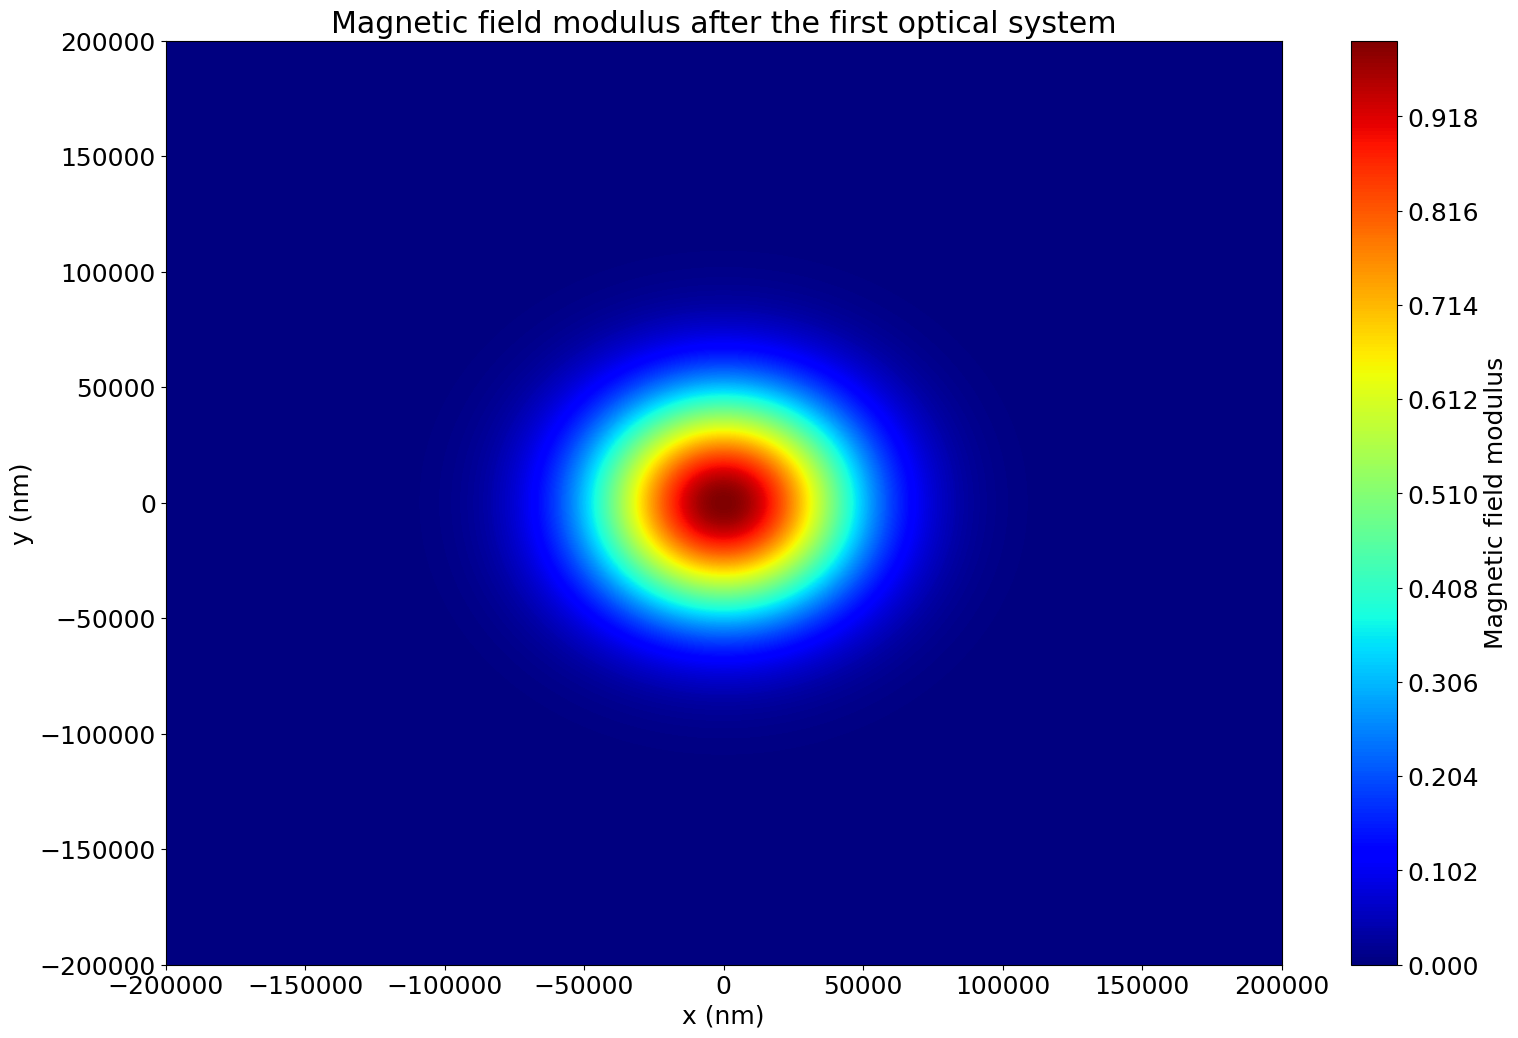

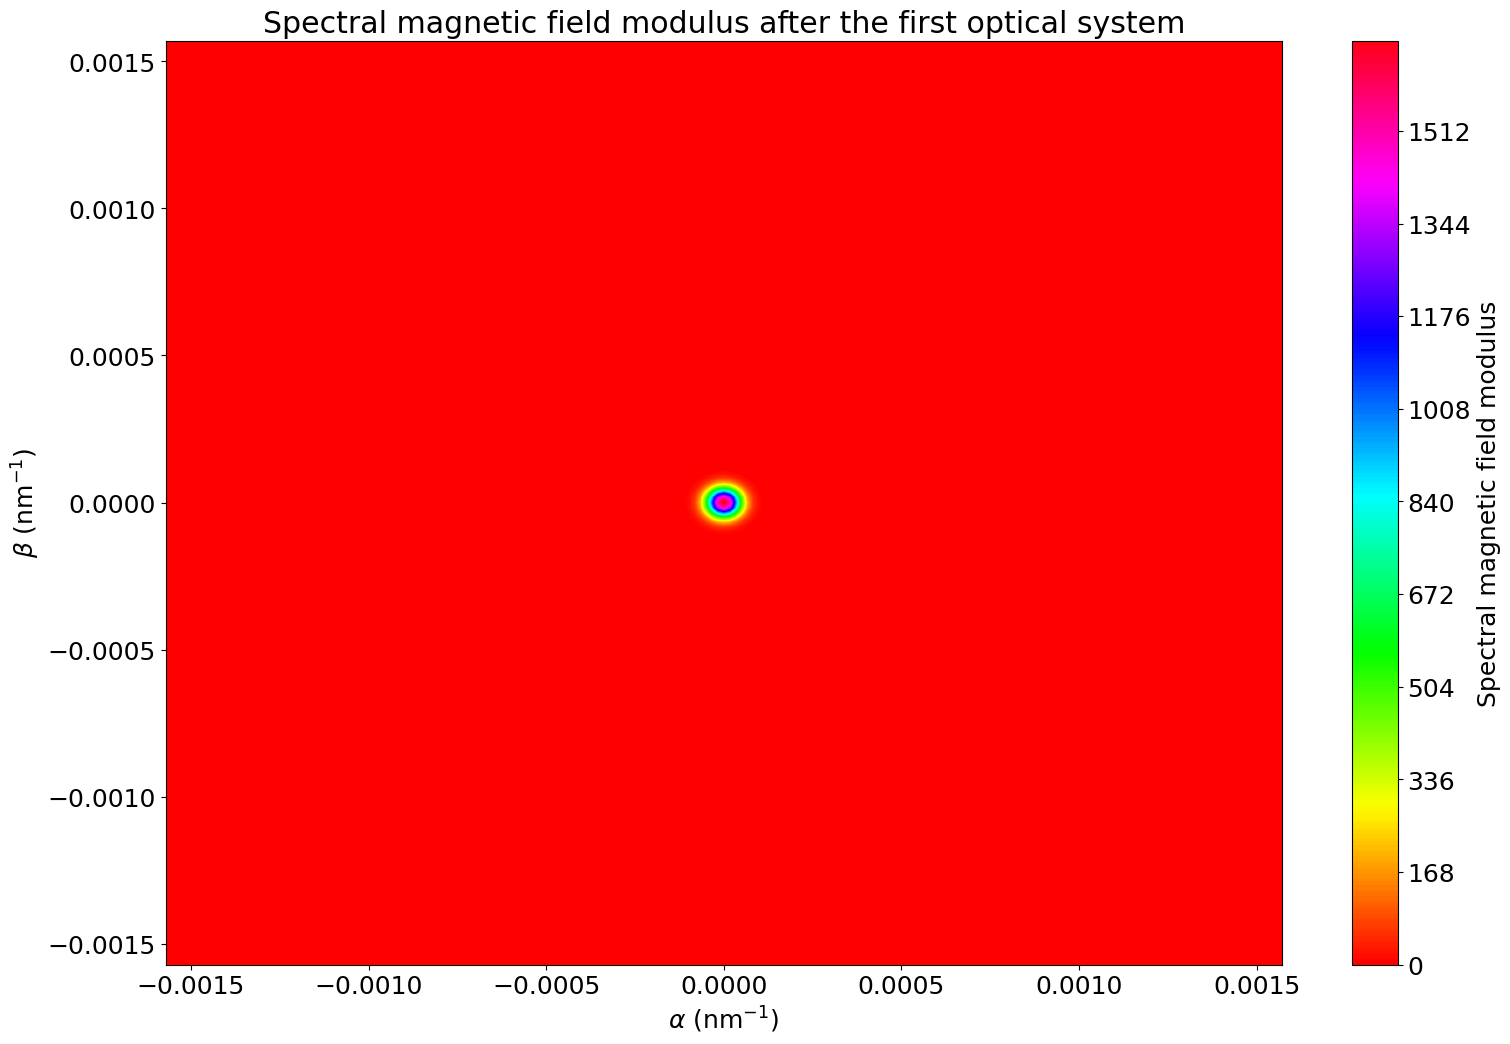

In [6]:
# plot of the spatial beam after SO1
U1 = my_mod.gauss2D(X, Y, wx, wy, x0, y0, n2*alpha0, beta0)
fig = plt.figure(figsize=(18, 12))
ax = fig.add_subplot(111)
contour = ax.contourf(X, Y, np.abs(U1), levels=500, cmap="jet")
contour.set_edgecolor("face")  
cbar = fig.colorbar(contour)
cbar.set_label("Magnetic field modulus")
ax.set_xlabel("x (nm)")
ax.set_ylabel("y (nm)")
ax.set_title("Magnetic field modulus after the first optical system")
if SAVE_MODE:
    for file_ext in save_formats:
        plt.savefig(f"Plots/{file_ext}/setup/H_module_before_reflection.{file_ext}", bbox_inches="tight")

# determination and plot of the spectral beam after SO1
pask = 2 * np.pi / d  # definition of the spectral step
U1k = fftshift(fftshift(fft2(U1), axes=0), axes=1)  # spectral beam determination
a = np.arange(-N, N + 1) * pask  # alpha (kx) range in nm-1
b = a  # beta (ky) range in nm-1
A, B = np.meshgrid(a, b)  # alpha and beta grid
fig = plt.figure(figsize=(18, 12))
ax = fig.add_subplot(111)
contour = ax.contourf(A, B, np.abs(U1k), levels=500, cmap="hsv")
contour.set_edgecolor("face")
cbar = fig.colorbar(contour)
cbar.set_label("Spectral magnetic field modulus")
ax.set_xlabel(r"$\alpha$ ($\mathrm{nm}^{-1}$)")
ax.set_ylabel(r"$\beta$ ($\mathrm{nm}^{-1}$)")
ax.set_title("Spectral magnetic field modulus after the first optical system");
if SAVE_MODE:
    for file_ext in save_formats:
        plt.savefig(f"Plots/{file_ext}/setup/spectral_H_module_before_reflection.{file_ext}", bbox_inches="tight")

### Reflection

Simulation of the beam reflection.

It is essential to note that expressing plane wave propagation using Fourier optics shows that the reflection coefficient $r(\alpha,\beta)$ does not need to be introduced at the actual interface location. Mathematically, for an interface at $d_1$ and propagation up to $d_1+d_2$:
\begin{equation*} \widetilde{H}(\alpha,\beta;d_1+d_2)=\widetilde{H}(\alpha,\beta;0).e^{ik_zd_1}.r(\alpha,\beta).e^{ik_zd_2}=\widetilde{H}(\alpha,\beta;0).e^{ik_z(d_1+d_2)}.r(\alpha,\beta). \end{equation*}

Since the transfer function related to propagation ($e^{ik_z d}$, where $d$ is the propagation distance) commutes with the reflection function, the reflection can be introduced at any point during the beam’s propagation inside the prism. Although numerical propagation of the beam is challenging, placing the reflection at the beam’s convergence point—on the image of the pinhole—ensures feasible numerical calculations, regardless of the actual position of this image.

The first step is to determine the incidence angle associated to each plane wave of the beam.

In [7]:
kz = ((n2 * k0) ** 2 - A**2 - B**2) ** (1 / 2)  # determination of the wave vector z component (kz or gamma) for all incident plane wave
theta = np.arcsin(np.sqrt((A * np.cos(np.deg2rad(inc)) + kz * np.sin(np.deg2rad(inc))) ** 2 + B**2)/ (n2 * k0))  # array with the incidence angle for all incident plane wave
cr = np.zeros((2 * N + 1, 2 * N + 1), dtype=complex)  # initialisation of the array of reflection coefficient for all incident plane wave, with complexe numbers
# 1D (to align resonance)
thetaproj1D = theta[N, :]  # array of incidence angle for beta (ky) = 0
cr1D = np.zeros(2 * N + 1, dtype=complex)  # initialisation of the array of reflection coefficient for incident plane wave with beta = 0, with complex numbers

Definition of the structure on which the reflection is done.

In [8]:
# get the material from refractiveindex database (RII) when possible
Cr = PM.Material(["main", "Cr", "Rakic-BB"], specialType="RII")
Au = PM.Material(["main", "Au", "Rakic-BB"], specialType="RII")
h_Au = 47 # gold layer thickness

mat = ["BK7",Cr,Au,1.33**2]  # list with all the materials needed, BK7 taken from PM .json because the one in RII don't match the wavelength, and 1.33**2 is for water
stack = [0, 1, 2, 3]  # stacking order of the materials in the  multilayered structure
thickness = [4000, 2, h_Au, 1000]  # thickness of each layer
structure = PM.Structure(mat, stack, thickness, verbose=False)

Determination of the reflection coefficients for each plane wave and plot of them.

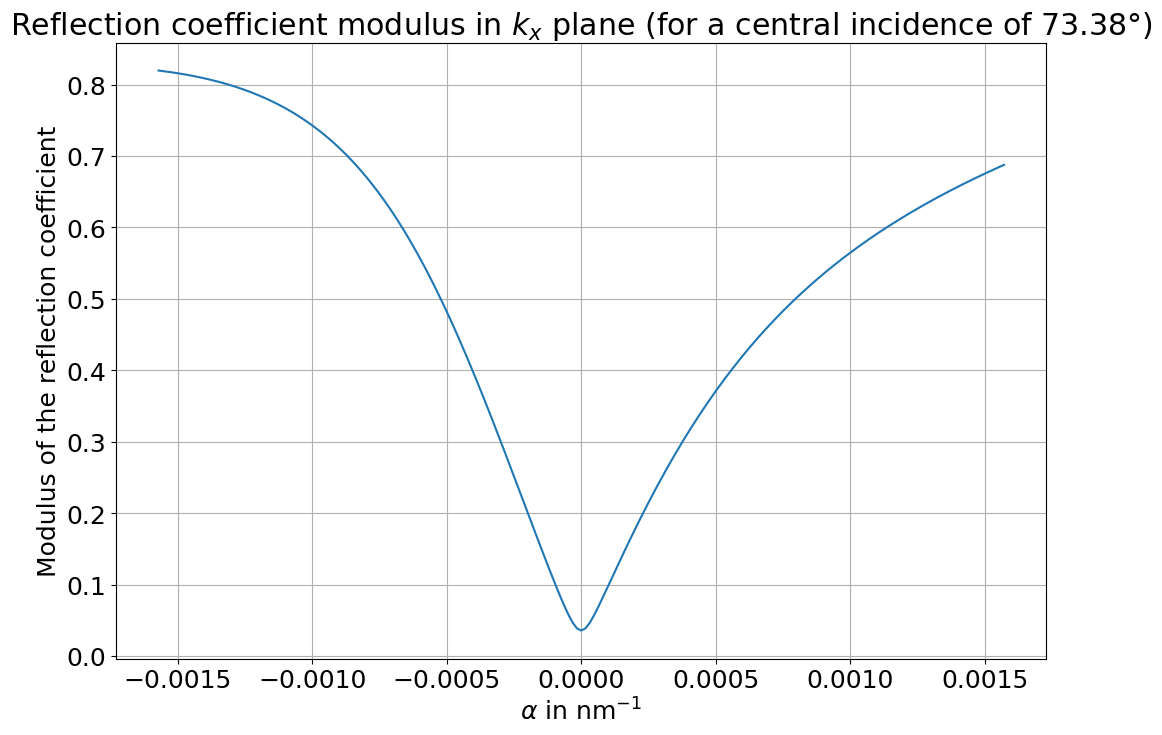

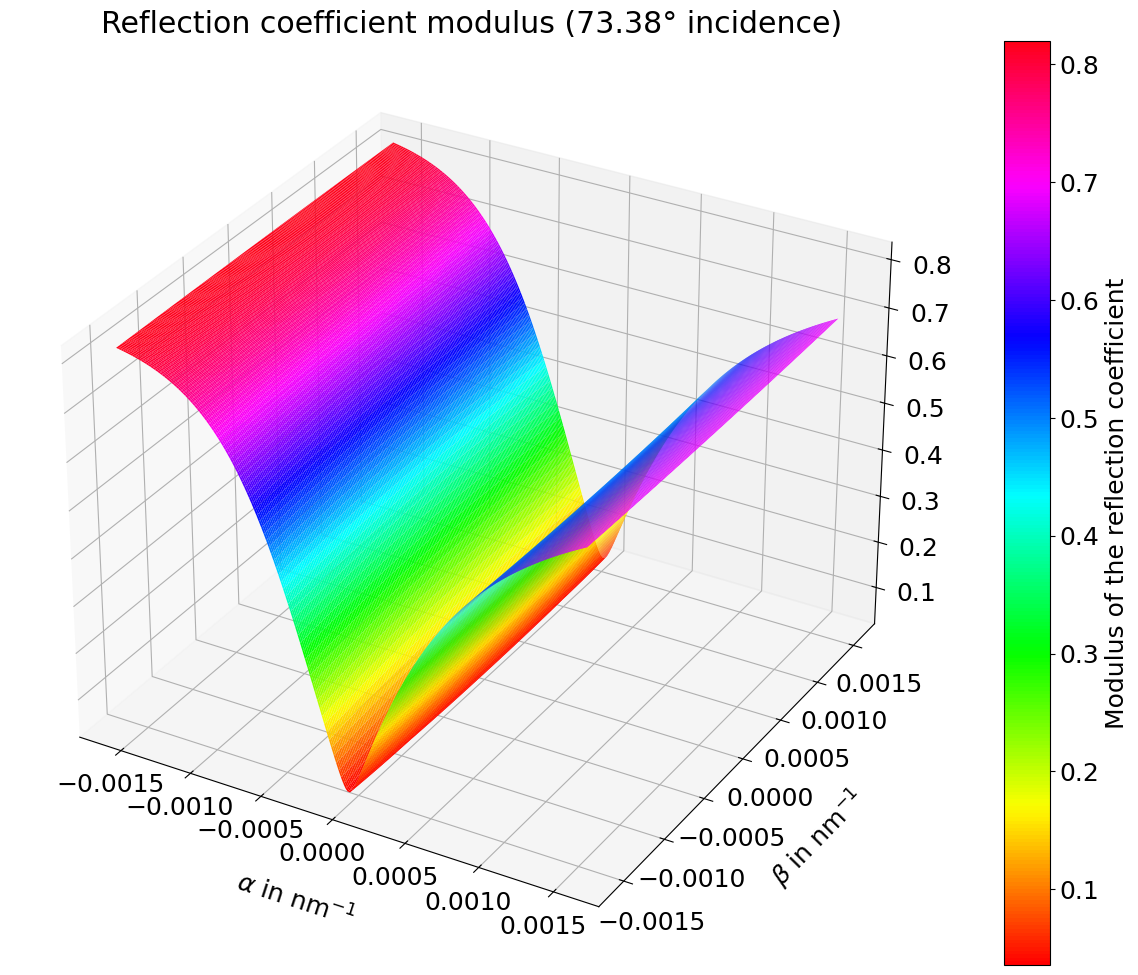

In [9]:
for i in range(len(a)):
    r, t, R, T = PM.coefficient(structure, wavelength, thetaproj1D[i], 1)  #  PM function computing the Fersnel coefficients for structure, for wavelength, for the incidence angle given and with a TM polarity
    cr1D[i] = r

plt.figure(figsize=(12,8))
plt.plot(a,np.abs(cr1D))
plt.title(fr"Reflection coefficient modulus in $k_x$ plane (for a central incidence of {inc}°)")
plt.xlabel(r"$\alpha$ in $\mathrm{nm}^{-1}$")
plt.ylabel(fr"Modulus of the reflection coefficient")
plt.grid();
if SAVE_MODE:
    for file_ext in save_formats:
        plt.savefig(f"Plots/{file_ext}/setup/reflection_coefficient_module_1D.{file_ext}", bbox_inches="tight")

for i in range(len(a)):
    for j in range(len(b)):
        r, t, R, T = PM.coefficient(structure, wavelength, theta[i,j], 1)
        cr[i, j] = r

fig=plt.figure(figsize=(18,12))
ax = fig.add_subplot(111, projection='3d', )
surf = ax.plot_surface(A, B, abs(cr), cmap='hsv', edgecolor='none',rcount=2*N+1,ccount=2*N+1,vmin=np.min(abs(cr)),vmax=np.max(abs(cr)))
col=fig.colorbar(surf)
ax.set_xlabel(r"$\alpha$ in $\mathrm{nm}^{-1}$", labelpad=20)
ax.set_ylabel(r"$\beta$ in $\mathrm{nm}^{-1}$", labelpad=30)
col.set_label("Modulus of the reflection coefficient")
ax.set_title(fr"Reflection coefficient modulus ({inc}° incidence)")
ax.xaxis.label.set_rotation_mode('anchor')
ax.yaxis.label.set_rotation_mode('anchor')
ax.tick_params(axis='y', pad=10)
ax.tick_params(axis='z', pad=10);
if SAVE_MODE:
    for file_ext in save_formats:
        plt.savefig(f"Plots/{file_ext}/setup/reflection_coefficient_module.{file_ext}", bbox_inches="tight")


#### a standalone check of the compatibility of my r as function of the incidence and the one given by PM.angular
angle_check, r_check, t_check, R_check, T_check = PM.angular(structure, wavelength,1, 67, 80,10000)

plt.figure(figsize=(12,8))
plt.plot(angle_check,np.abs(r_check))
plt.plot(np.rad2deg(thetaproj1D), np.abs(cr1D));

print(np.min(np.abs(r_check)), np.min(np.abs(cr1D)),np.min(np.abs(r_check))/np.min(np.abs(cr1D)))

Reflection coefficients application on the beam and plots of the magnetic field after reflection.

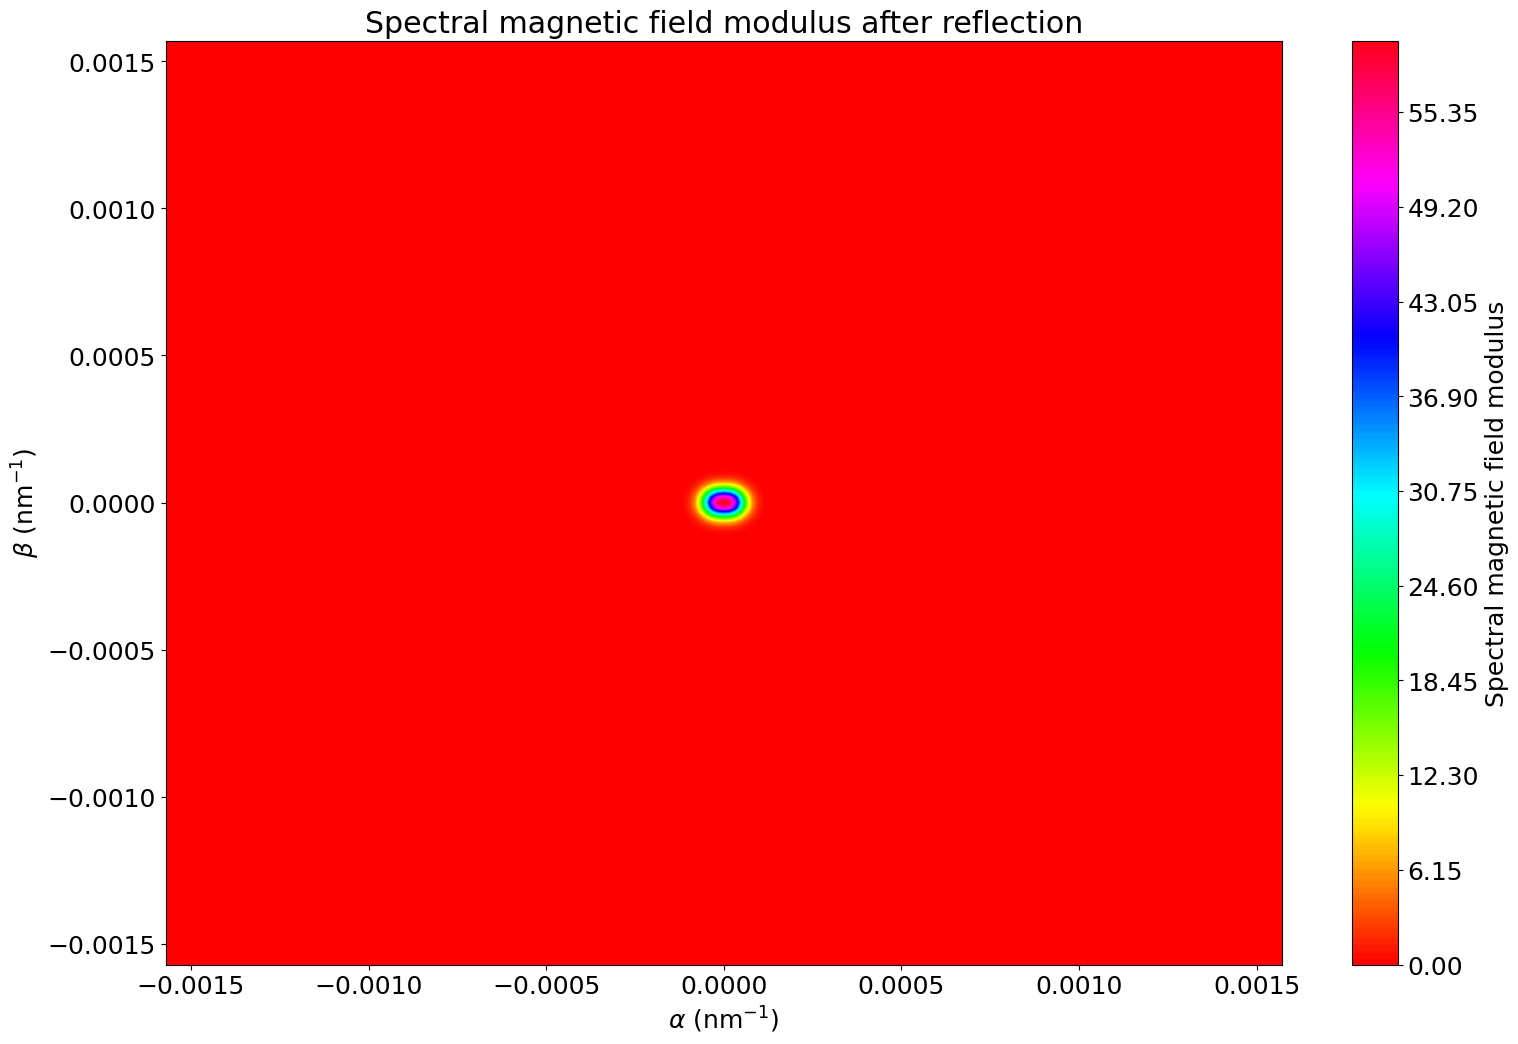

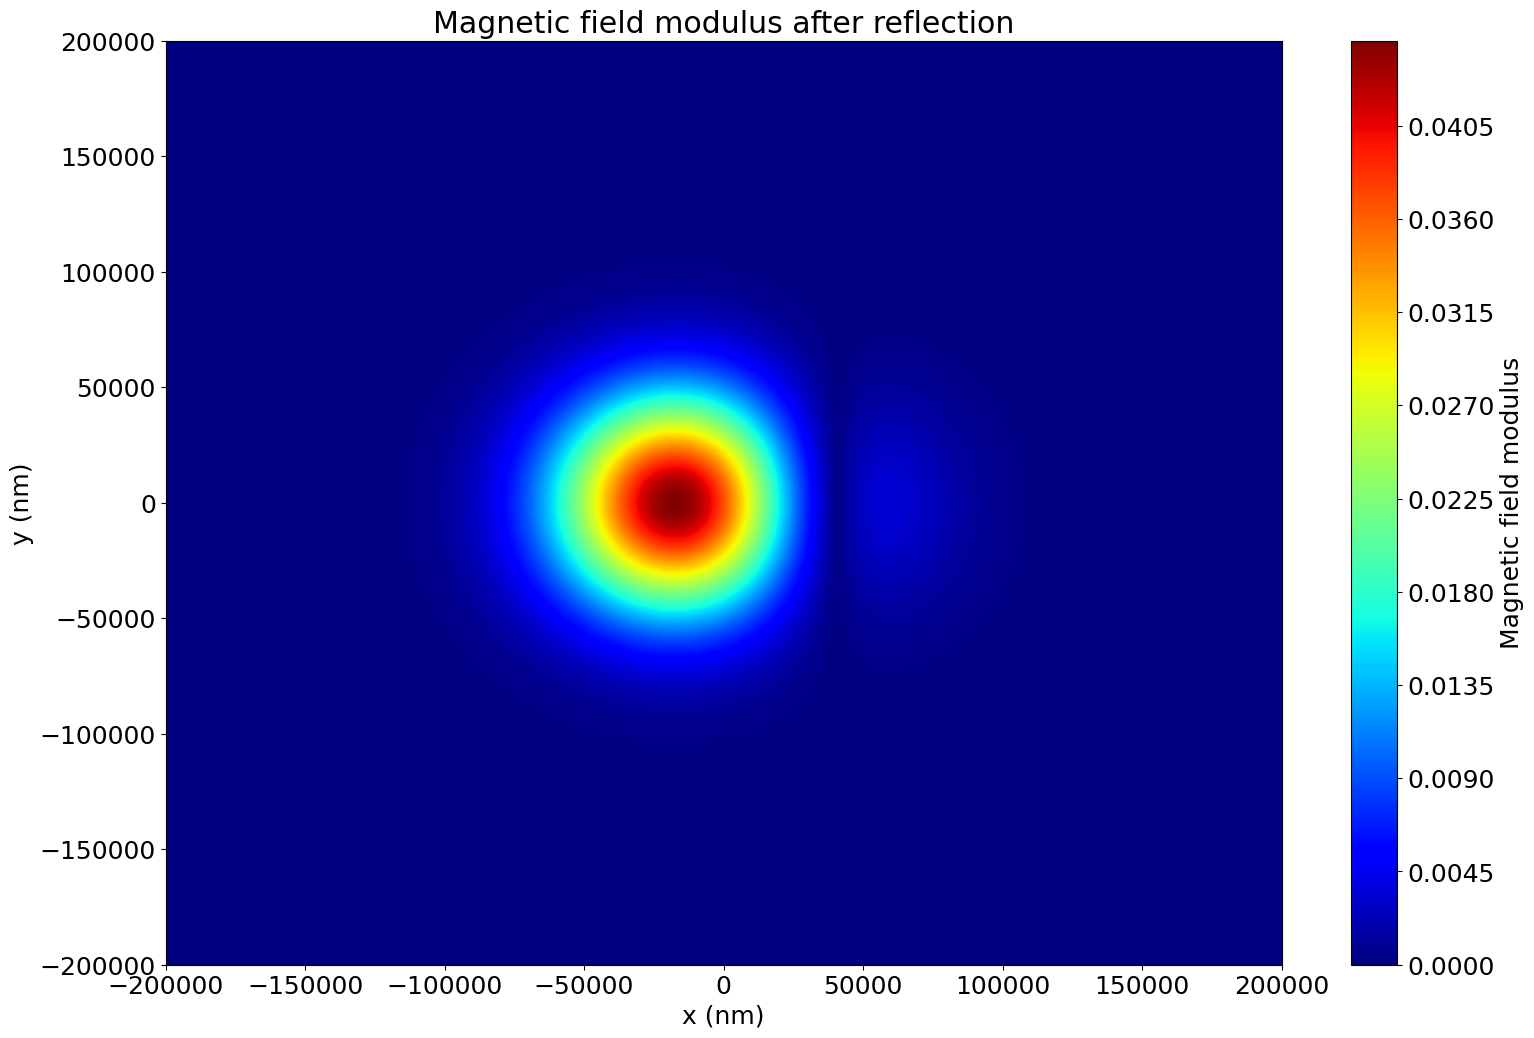

In [10]:
U1ki=cr*U1k # on the spectral beam
U1i=ifft2(U1ki) # redetermination of the physical beam

fig = plt.figure(figsize=(18, 12))
ax = fig.add_subplot(111)
contour = ax.contourf(A, B, np.abs(U1ki), levels=500, cmap="hsv")
contour.set_edgecolor("face")
cbar = fig.colorbar(contour)
cbar.set_label("Spectral magnetic field modulus")
ax.set_xlabel(r"$\alpha$ ($\mathrm{nm}^{-1}$)")
ax.set_ylabel(r"$\beta$ ($\mathrm{nm}^{-1}$)")
ax.set_title("Spectral magnetic field modulus after reflection");
if SAVE_MODE:
    for file_ext in save_formats:
        plt.savefig(f"Plots/{file_ext}/setup/spectral_H_module_after_reflection.{file_ext}", bbox_inches="tight")

fig = plt.figure(figsize=(18, 12))
ax = fig.add_subplot(111)
contour = ax.contourf(X, Y, np.abs(U1i), levels=500, cmap="jet")
contour.set_edgecolor("face")
cbar = fig.colorbar(contour)
cbar.set_label("Magnetic field modulus")
ax.set_xlabel("x (nm)")
ax.set_ylabel("y (nm)")
ax.set_title("Magnetic field modulus after reflection");
if SAVE_MODE:
    for file_ext in save_formats:
        plt.savefig(f"Plots/{file_ext}/setup/H_module_after_reflection.{file_ext}", bbox_inches="tight")


Determination of the beam shift ($\delta$) and the beam enlargement ($\Delta$) due to the reflection, defined on each axis of the 2D grid as :

\begin{align*}
    \delta_x &= \frac{\iint x |H_r|^2 \mathrm{d}x\mathrm{d}y}{\iint |H_r|^2 \mathrm{d}x \mathrm{d}y}-\frac{\iint x |H_i|^2 \mathrm{d}x\mathrm{d}y}{\iint |H_i|^2 \mathrm{d}x \mathrm{d}y},
    \\
    \delta_y &= \frac{\iint y |H_r|^2 \mathrm{d}x\mathrm{d}y}{\iint |H_r|^2 \mathrm{d}x \mathrm{d}y}-\frac{\iint y |H_i|^2 \mathrm{d}x\mathrm{d}y}{\iint |H_i|^2 \mathrm{d}x \mathrm{d}y},
\end{align*}

\begin{align*}
\Delta_{x}  &= \frac{\iint (x-\delta_{x})^2|H_r|^2 \mathrm{d}x\mathrm{d}y}{\iint |H_r|^2 \mathrm{d}x\mathrm{d}y}-\frac{\iint x^2|H_i|^2\mathrm{d}x\mathrm{d}y}{\iint |H_i|^2 \mathrm{d}x\mathrm{d}y},
\\
\Delta_{y}  &= \frac{\iint (y-\delta_{y})^2|H_r|^2\mathrm{d}x\mathrm{d}y}{\iint |H_r|^2\mathrm{d}x\mathrm{d}y}-\frac{\iint y^2|H_i|^2\mathrm{d}x\mathrm{d}y}{\iint |H_i|^2 \mathrm{d}x\mathrm{d}y}.
\end{align*}
where $H_i$ denotes the incoming magnetic field and $H_r$ denotes the reflected magnetic field.

In [11]:
# determination of the barycentre of the beam on x and y for the incoming and the reflected beam
bxU1  = trapezoid(trapezoid(X * np.abs(U1)**2, x, axis=1), y) / trapezoid(trapezoid(np.abs(U1)**2, x, axis=1), y)
byU1  = trapezoid(trapezoid(Y * np.abs(U1)**2, x, axis=1), y) / trapezoid(trapezoid(np.abs(U1)**2, x, axis=1), y)
bxU1i = trapezoid(trapezoid(X * np.abs(U1i)**2, x, axis=1), y) / trapezoid(trapezoid(np.abs(U1i)**2, x, axis=1), y)
byU1i = trapezoid(trapezoid(Y * np.abs(U1i)**2, x, axis=1), y) / trapezoid(trapezoid(np.abs(U1i)**2, x, axis=1), y)

# determination of the shift
decx=bxU1i-bxU1
decy=byU1i-byU1

# determination of the enlargement (in absolute and relative form)
elarx = (trapezoid(trapezoid(((X - decx)**2) * (np.abs(U1i)**2), x, axis=1), y) / trapezoid(trapezoid(np.abs(U1i)**2, x, axis=1), y)) - (trapezoid(trapezoid((X**2) * (np.abs(U1)**2), x, axis=1), y) / trapezoid(trapezoid(np.abs(U1)**2, x, axis=1), y))
elary = (trapezoid(trapezoid(((Y - decy)**2) * (np.abs(U1i)**2), x, axis=1), y) / trapezoid(trapezoid(np.abs(U1i)**2, x, axis=1), y)) - (trapezoid(trapezoid((Y**2) * (np.abs(U1)**2), x, axis=1), y) / trapezoid(trapezoid(np.abs(U1)**2, x, axis=1), y))
elarrelatx = (trapezoid(trapezoid(((X - decx)**2) * (np.abs(U1i)**2), x, axis=1), y) / trapezoid(trapezoid(np.abs(U1i)**2, x, axis=1), y)) / (trapezoid(trapezoid((X**2) * (np.abs(U1)**2), x, axis=1), y) / trapezoid(trapezoid(np.abs(U1)**2, x, axis=1), y))
elarrelaty = (trapezoid(trapezoid(((Y - decy)**2) * (np.abs(U1i)**2), x, axis=1), y) / trapezoid(trapezoid(np.abs(U1i)**2, x, axis=1), y)) / (trapezoid(trapezoid((Y**2) * (np.abs(U1)**2), x, axis=1), y) / trapezoid(trapezoid(np.abs(U1)**2, x, axis=1), y))

print(f"x shift: {decx} nm")
print(f"y shift: {decy} nm")
print(f"x enlargement: {elarx} nm^2")
print(f"y enlargement: {elary} nm^2")
print(f"x relative enlargement: {elarrelatx}")
print(f"y relative enlargement: {elarrelaty}")

x shift: -19081.488127379824 nm
y shift: -1.70037817969845e-13 nm
x enlargement: -132912784.71254522 nm^2
y enlargement: 690.9034205079079 nm^2
x relative enlargement: 0.7508348606023413
y relative enlargement: 1.0000012952030721


### Second optical system

Beam propagation through the second optical system (spherical diopter + lens) SO2. The propagation is done similarly to SO1.

To correspond to a possible experiment, a charge-coupled device (CCD) is placed at the image focus of SO2 to measure the beam properties. We assume a CCD with 256 × 1024 pixels, each 26 $\mu m$ in size, sampling the signal. The simulation is also sampled with 2 $\mu m$ pixels, resulting from a discretization of space into 201 points per axis over 400 $\mu m$. To meet Shannon's criterion, which requires at least two pixels per spatial resolution element, a magnification of 30 would be adequate (this is the SO2 target).

The geometrical parameter of SO2 are provided in $mm$.

In [12]:
G2cible = 30 # SO2 targeted magnification

AiS=2*SI-SAiid # distance SO1 image to SO2 spherical diopter top
SA=-AiS # distance SO2 spherical diopter to SO2 object (= SO1 image)
SC2=-13.1 # radius of curvature of the spherical diopter (or plan convex lens) with a - here because concave
f2 = 35  # lens focus

# finding realistic parameters to reach the targeted magnification
G2id=0 # optimal magnification
Delta2id=0 # optimal optic interval or distance between the image focus of the spherical diopter and the object focus of the lens
AAifid=0 # optimal distance between object and image
OAifid=0 # optimal distance between lens and image
SOid=0 # optimal distance between spherical diopter and lens

# loops to scan the optic interval
# in order to search for the best configuration of SO2 to reach the targeted magnification (the sign do not matter, the image can be inverted) with a realistic configuration
for Delta2 in range(-500, 501, 1):
    # print(Delta)
    SO, OAif, AAif, G2 = my_mod.SO2(n1, f2, n2, SC2, SA, Delta2)
    if ((abs(abs(G2) - G2cible) < abs(abs(G2id) - G2cible)) and (SO > 0) and (OAif >= 0) and (OAif <= 1000)):
        G2id=G2
        Delta2id=Delta2
        AAifid=AAif
        OAifid=OAif
        SOid=SO

print(f"Optimal optic interval: {Delta2id} mm")
print(f"Optimal object - image distance: {AAifid} mm")
print(f"Optimal distance sherical diopter - lens: {SOid} mm")
print(f"Optimal distance lens - image (or CCD): {OAifid} mm")
print(f"Optimal magnification of {G2id} for a targeted magnification of {G2cible}")


Optimal optic interval: -30 mm
Optimal object - image distance: 808.1431650938096 mm
Optimal distance sherical diopter - lens: 30.4368932038835 mm
Optimal distance lens - image (or CCD): 770.1251983783689 mm
Optimal magnification of -26.147348560405227 for a targeted magnification of 30


Plot of the magnetic field at CCD.

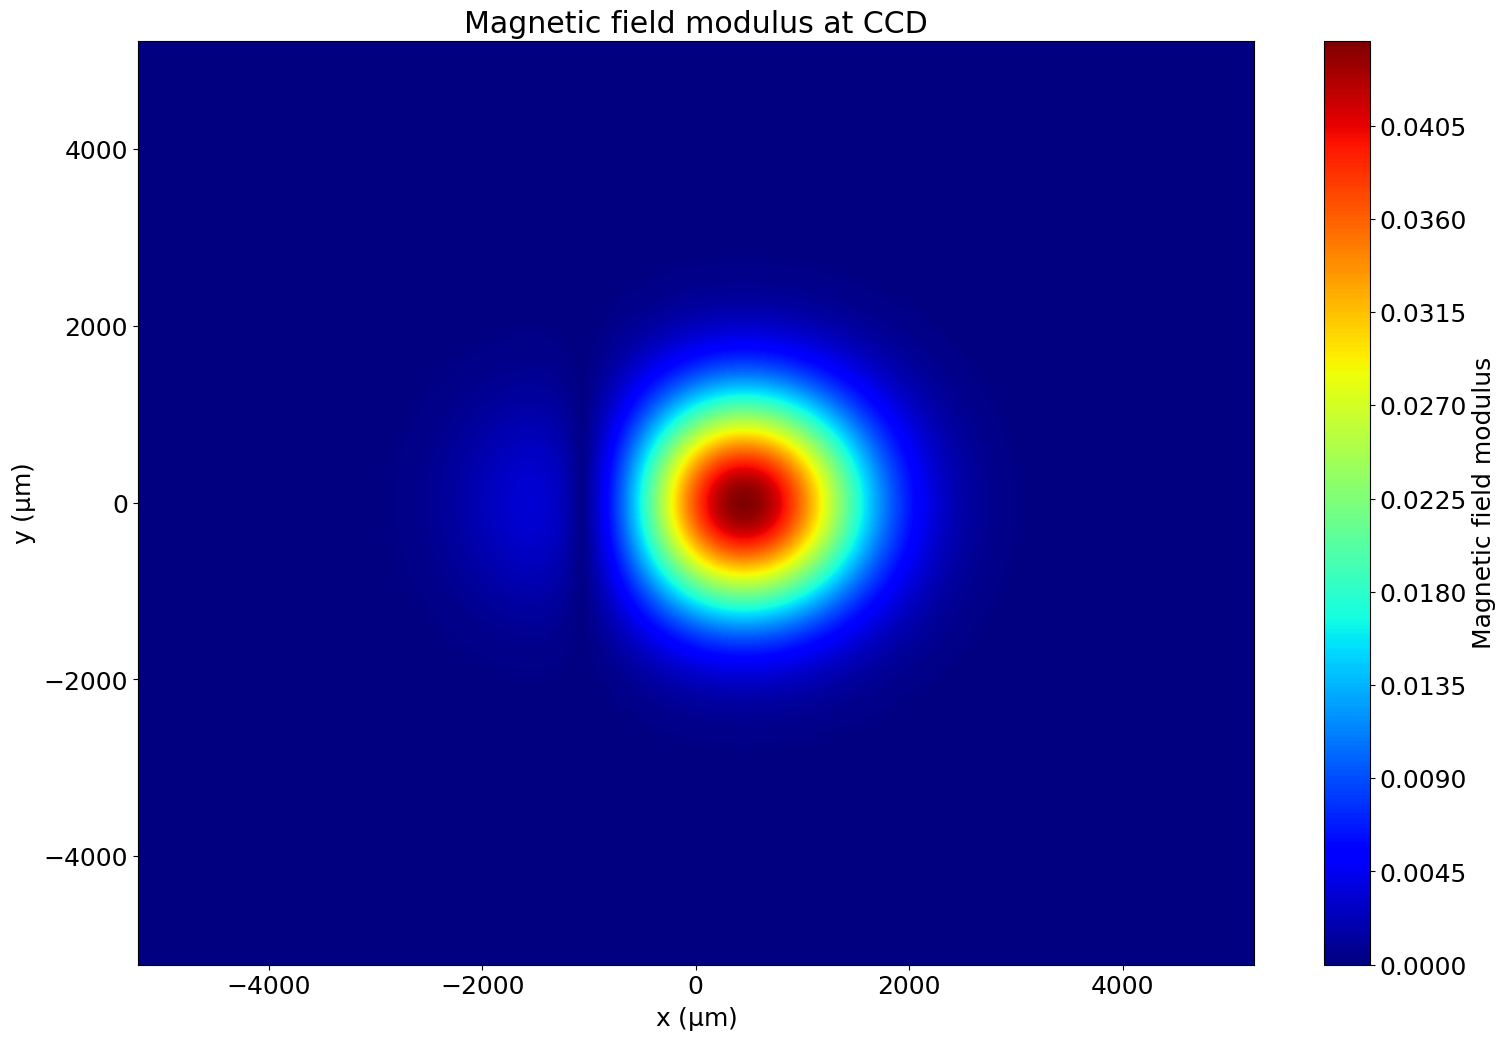

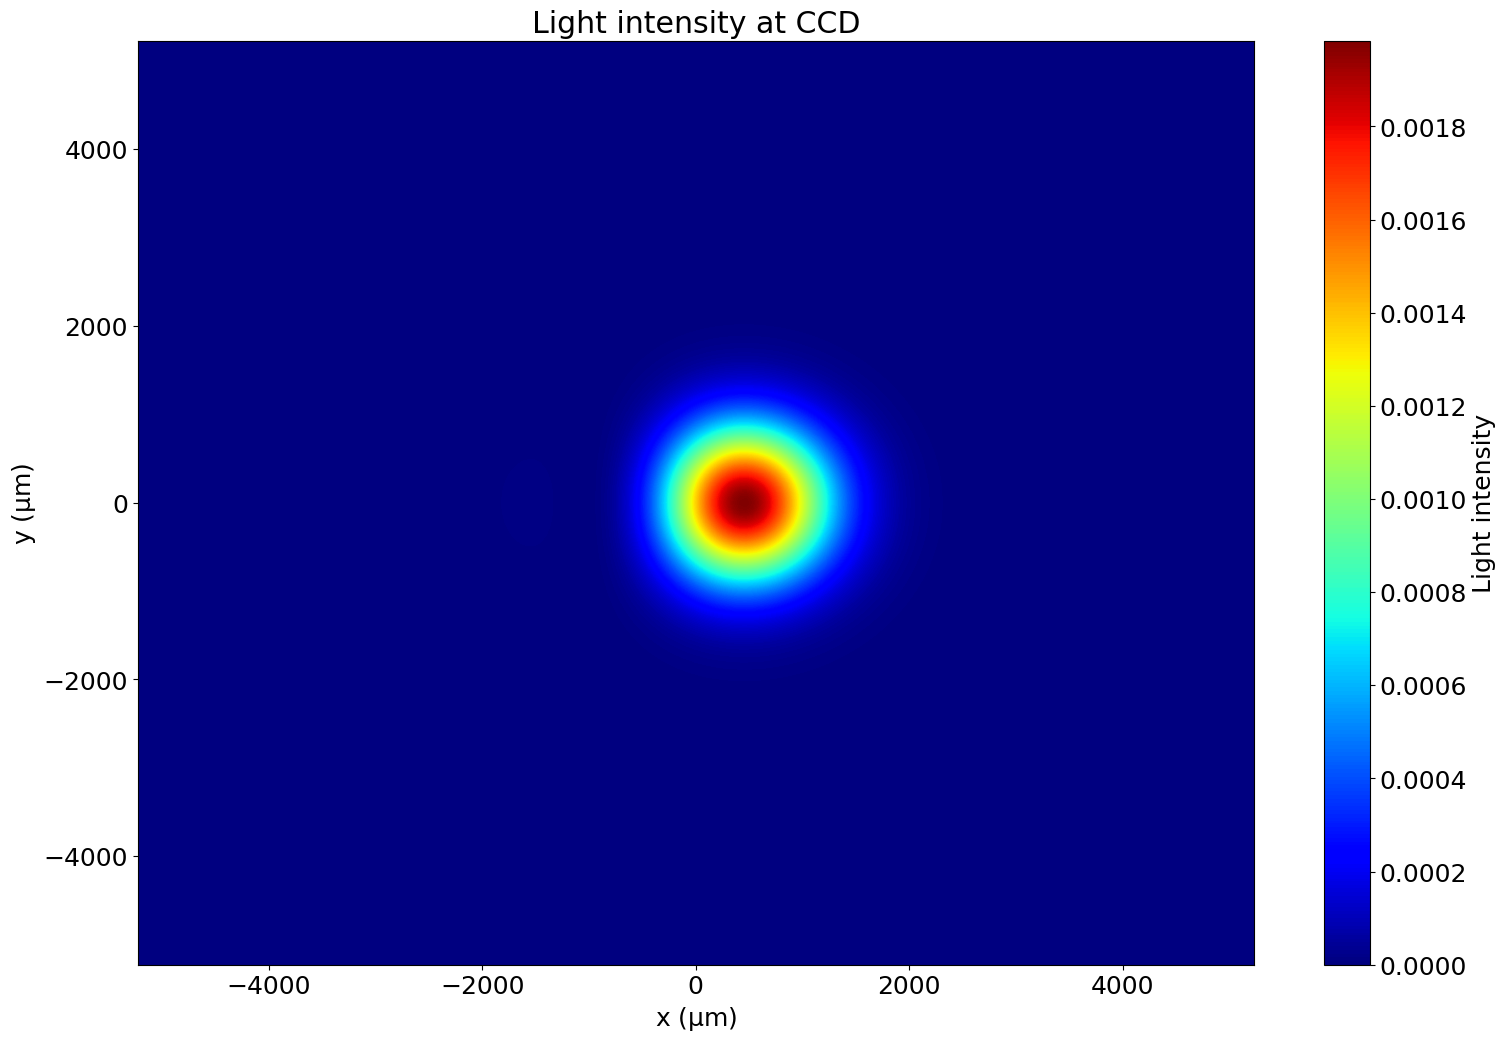

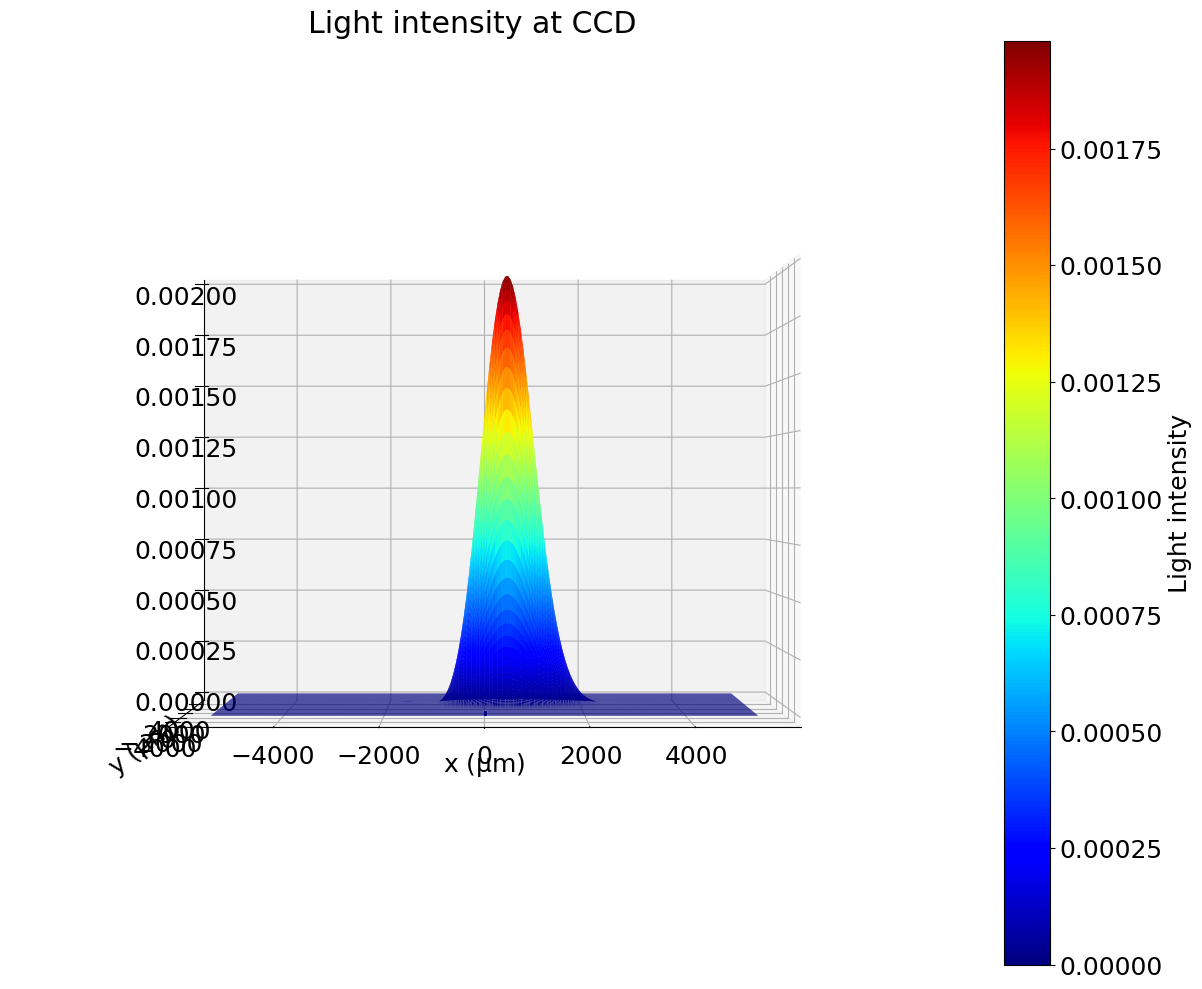

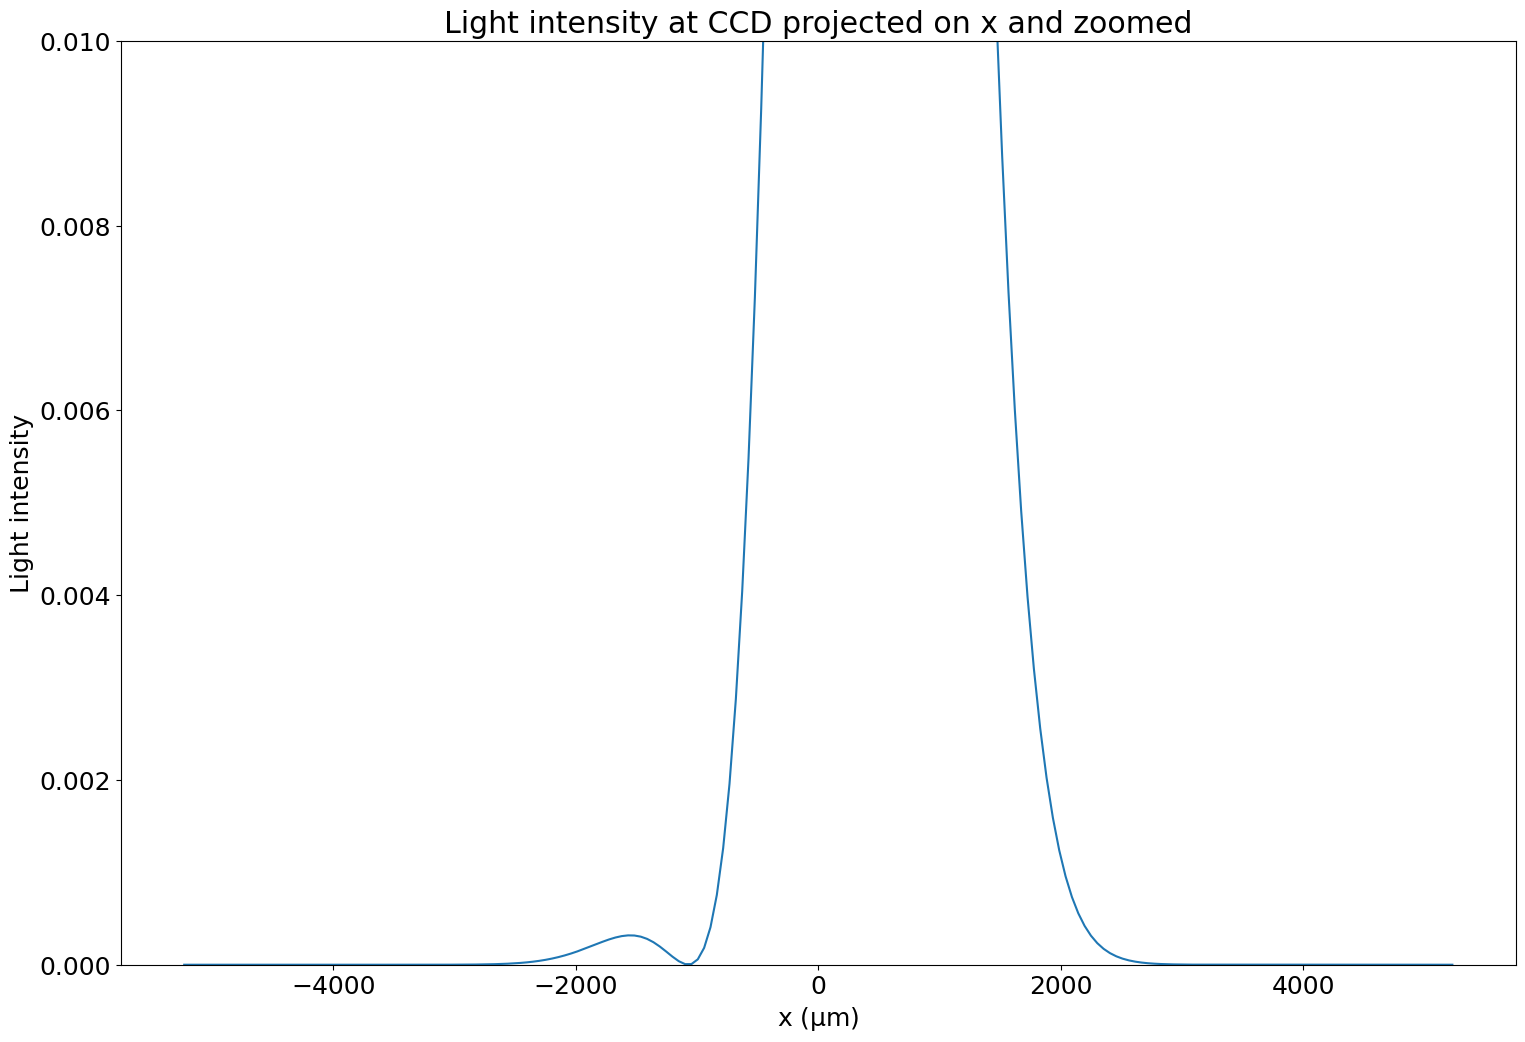

In [13]:
G2 = G2id

# here G2 is applied to the axes
fig = plt.figure(figsize=(18, 12))
ax = fig.add_subplot(111)
contour = ax.contourf(X*G2/1000, Y*G2/1000, np.abs(U1i), levels=500, cmap="jet")
contour.set_edgecolor("face")
cbar = fig.colorbar(contour)
cbar.set_label("Magnetic field modulus")
ax.set_xlabel(r"x ($\mathrm{\mu m}$)")
ax.set_ylabel(r"y ($\mathrm{\mu m}$)")
ax.set_title("Magnetic field modulus at CCD");
if SAVE_MODE:
    for file_ext in save_formats:
        plt.savefig(f"Plots/{file_ext}/setup/H_module_at_CCD.{file_ext}", bbox_inches="tight")

fig = plt.figure(figsize=(18, 12))
ax = fig.add_subplot(111)
contour = ax.contourf(X*G2/1000, Y*G2/1000, np.abs(U1i)**2, levels=500, cmap="jet")
contour.set_edgecolor("face")
cbar = fig.colorbar(contour)
cbar.set_label("Light intensity")
ax.set_xlabel(r"x ($\mathrm{\mu m}$)")
ax.set_ylabel(r"y ($\mathrm{\mu m}$)")
ax.set_title("Light intensity at CCD");
if SAVE_MODE:
    for file_ext in save_formats:
        plt.savefig(f"Plots/{file_ext}/setup/light_intensity_at_CCD.{file_ext}", bbox_inches="tight")

fig=plt.figure(figsize=(18,12))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X*G2/1000, Y*G2/1000, np.abs(U1i)**2, cmap='jet', edgecolor='none',rcount=2*N+1,ccount=2*N+1,vmin=np.min(np.abs(U1i)**2),vmax=np.max(np.abs(U1i)**2))
colb = fig.colorbar(surf)
ax.set_xlabel(r"x ($\mathrm{\mu m}$)")
ax.set_ylabel(r"y ($\mathrm{\mu m}$)")
colb.set_label('Light intensity')
ax.set_title('Light intensity at CCD')
ax.view_init(elev=0,azim=-90);

fig=plt.figure(figsize=(18,12))
plt.plot(x*G2/1000, np.sum(np.abs(U1i)**2, axis=0))
# plt.plot(x*G2/1000, ((np.abs(U1i)**2)[N]))
plt.xlabel(r"x ($\mathrm{\mu m}$)")
plt.ylabel("Light intensity")
plt.title("Light intensity at CCD projected on x and zoomed")
plt.ylim(0,0.01);

Summary of the system:

In [14]:
print(f"Incidence angle: {inc}°")
print(f"Pinhole - first lens distance: {-OAid} mm")
print(f"First lens focus: {f1} mm")
print(f"First lens - first sherical diopter distance: {OSid} mm")
print(f"SO1 magnification: {G}")
print(f"Second lens focus: {f2} mm")
print(f"Distance second sherical diopter - second lens: {SOid} mm")
print(f"Distance second lens - CCD: {OAifid} mm")
print(f"SO2 magnification: {G2}")
print(f"x shift: {decx} nm")
print(f"y shift: {decy} nm")
print(f"x relative enlargement: {elarrelatx}")
print(f"y relative enlargement: {elarrelaty}")

Incidence angle: 73.38°
Pinhole - first lens distance: 32 mm
First lens focus: 30 mm
First lens - first sherical diopter distance: 458.4368932038835 mm
SO1 magnification: -8.11815740549485
Second lens focus: 35 mm
Distance second sherical diopter - second lens: 30.4368932038835 mm
Distance second lens - CCD: 770.1251983783689 mm
SO2 magnification: -26.147348560405227
x shift: -19081.488127379824 nm
y shift: -1.70037817969845e-13 nm
x relative enlargement: 0.7508348606023413
y relative enlargement: 1.0000012952030721
